In [1]:
!pip -q install ipyleaflet contextily xyzservices rasterio pyproj pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 70.4 MB/s eta 0:00:00


# Coverage setting

In [21]:
# ============================================================
# INTERACTIVE BASEMAP BOUNDING-BOX + SCALE SELECTOR
# Google Colab
#
# Draw a rectangle manually.
#
# SCALE MODES:
#
#   TRUE
#       Use exactly what you drew.
#
#   FIXED
#       Fit to an exact entered scale.
#       Uses TABLOID automatically.
#
#   ROUND
#       Calculate scale from selection, then round it.
#       Uses TABLOID automatically.
#
# For FIXED / ROUND:
#
#   Wider selection  -> Tabloid Landscape
#   Taller selection -> Tabloid Portrait
#
# The adjusted extent always keeps the SAME CENTER.
#
# selected_bbox     = FINAL bbox used by export script
# raw_selected_bbox = original rectangle drawn by user
# ============================================================


# ============================================================
# SETTINGS — EDIT ONLY THIS SECTION
# ============================================================


# ------------------------------------------------------------
# STARTING LOCATION
# ------------------------------------------------------------

# Newton, Massachusetts

START_CENTER = (42.3370, -71.2092)

START_ZOOM = 14


# ------------------------------------------------------------
# SCALE MODE
# ------------------------------------------------------------

# Choose:
#
# "TRUE"
#     Keep the exact bounding box you draw.
#
# "FIXED"
#     Force map coverage to TARGET_SCALE.
#     Uses Tabloid automatically.
#
# "ROUND"
#     Calculate scale from selection,
#     then round to ROUND_BASE.
#     Uses Tabloid automatically.

SCALE_MODE = "ROUND"


# ------------------------------------------------------------
# FIXED SCALE
# ------------------------------------------------------------

# Used only when:
# SCALE_MODE = "FIXED"
#
# Example:
# 2000 = 1:2000
# 2500 = 1:2500

TARGET_SCALE = 2000


# ------------------------------------------------------------
# ROUNDING
# ------------------------------------------------------------

# Used only when:
# SCALE_MODE = "ROUND"
#
# 50:
#   1:2374 -> 1:2350
#
# 100:
#   1:2374 -> 1:2400

ROUND_BASE = 100


# Choose:
#
# "nearest"
#     mathematically nearest scale
#
# "up"
#     always round UP so original selected
#     area remains inside adjusted map

ROUND_METHOD = "nearest"


# ------------------------------------------------------------
# TABLOID SHEET SIZE
# ------------------------------------------------------------

# US Tabloid:
# 11 × 17 inches
#
# 11 in = 279.4 mm
# 17 in = 431.8 mm
#
# Orientation is detected automatically
# from the user's drawn rectangle.

TABLOID_SHORT_MM = 279.4

TABLOID_LONG_MM = 431.8


# ------------------------------------------------------------
# DISPLAY ADJUSTED EXTENT
# ------------------------------------------------------------

# True:
# Show fitted/export bbox in BLUE.
#
# False:
# Only show original red rectangle.

SHOW_ADJUSTED_BBOX = True


# ============================================================
# IMPORTS
# ============================================================

from google.colab import output

output.enable_custom_widget_manager()


from ipyleaflet import (
    Map,
    TileLayer,
    GeomanDrawControl,
    LayersControl,
    Rectangle
)

import ipywidgets as widgets

from IPython.display import display

from pyproj import Geod

import math


# ============================================================
# VALIDATE SETTINGS
# ============================================================

VALID_SCALE_MODES = [
    "TRUE",
    "FIXED",
    "ROUND"
]


if SCALE_MODE not in VALID_SCALE_MODES:

    raise ValueError(
        f"SCALE_MODE must be one of: "
        f"{VALID_SCALE_MODES}"
    )


if ROUND_BASE not in [50, 100]:

    raise ValueError(
        "ROUND_BASE should normally be 50 or 100."
    )


if ROUND_METHOD not in [
    "nearest",
    "up"
]:

    raise ValueError(
        "ROUND_METHOD must be "
        "'nearest' or 'up'."
    )


if TABLOID_SHORT_MM <= 0:

    raise ValueError(
        "TABLOID_SHORT_MM must be greater than zero."
    )


if TABLOID_LONG_MM <= 0:

    raise ValueError(
        "TABLOID_LONG_MM must be greater than zero."
    )


if TARGET_SCALE <= 0:

    raise ValueError(
        "TARGET_SCALE must be greater than zero."
    )


# ============================================================
# GEODESIC ENGINE
# ============================================================

# WGS84 ellipsoid.
#
# Used to measure actual approximate ground
# distances rather than Web Mercator distances.

geod = Geod(
    ellps="WGS84"
)


# ============================================================
# NAVIGATION BASEMAP
# ============================================================

navigation_tiles = TileLayer(

    url=(
        "https://{s}.basemaps.cartocdn.com/"
        "rastertiles/voyager/"
        "{z}/{x}/{y}{r}.png"
    ),

    attribution=(
        "© OpenStreetMap contributors © CARTO"
    ),

    name="Navigation Map"
)


# ============================================================
# CREATE MAP
# ============================================================

m = Map(

    center=START_CENTER,

    zoom=START_ZOOM,

    layers=(
        navigation_tiles,
    ),

    scroll_wheel_zoom=True
)


m.layout.height = "650px"


# ============================================================
# RECTANGLE DRAWING TOOL
# ============================================================

draw = GeomanDrawControl(

    rectangle={

        "pathOptions": {

            "color": "#ff0000",

            "weight": 2,

            "fillOpacity": 0.08
        }
    },

    marker={},

    circle={},

    circlemarker={},

    polyline={},

    polygon={},

    text={},

    edit=True,

    remove=True,

    drag=False,

    cut=False,

    rotate=False
)


m.add(draw)


m.add(
    LayersControl(
        position="topright"
    )
)


# ============================================================
# STORED VALUES
# ============================================================

# Original rectangle drawn by user

raw_selected_bbox = None


# Final bbox used by export script

selected_bbox = None


# Final selected scale denominator
#
# Example:
# 2000 means 1:2000

selected_scale = None


# Detected Tabloid orientation

selected_orientation = None


# Actual map frame dimensions after
# orientation detection

MAP_WIDTH_MM = None

MAP_HEIGHT_MM = None


# Blue adjusted rectangle

adjusted_rectangle = None


# Output area

bbox_output = widgets.Output()


# ============================================================
# EXTRACT BOUNDING BOX
# ============================================================

def extract_bbox(feature):

    """
    Extract:
        west, south, east, north

    from a GeoJSON Polygon.
    """

    geometry = feature.get(
        "geometry",
        {}
    )


    if geometry.get("type") != "Polygon":

        return None


    ring = geometry[
        "coordinates"
    ][0]


    lons = [
        point[0]
        for point in ring
    ]


    lats = [
        point[1]
        for point in ring
    ]


    west = min(lons)

    east = max(lons)

    south = min(lats)

    north = max(lats)


    return (
        west,
        south,
        east,
        north
    )


# ============================================================
# BBOX CENTER
# ============================================================

def get_bbox_center(bbox):

    """
    Return center longitude and latitude.
    """

    west, south, east, north = bbox


    center_lon = (
        west + east
    ) / 2


    center_lat = (
        south + north
    ) / 2


    return (
        center_lon,
        center_lat
    )


# ============================================================
# MEASURE BBOX IN METERS
# ============================================================

def bbox_ground_size(bbox):

    """
    Measure approximate ground width and height
    of bounding box in meters using WGS84.
    """

    west, south, east, north = bbox


    center_lon, center_lat = (
        get_bbox_center(bbox)
    )


    # Width at center latitude

    _, _, width_m = geod.inv(

        west,
        center_lat,

        east,
        center_lat
    )


    # Height at center longitude

    _, _, height_m = geod.inv(

        center_lon,
        south,

        center_lon,
        north
    )


    return (
        abs(width_m),
        abs(height_m)
    )


# ============================================================
# DETECT TABLOID ORIENTATION
# ============================================================

def detect_tabloid_orientation(bbox):

    """
    Detect whether the user's selected area
    should use Tabloid landscape or portrait.

    Wider ground coverage:
        17 × 11 inches
        431.8 × 279.4 mm

    Taller ground coverage:
        11 × 17 inches
        279.4 × 431.8 mm
    """

    width_m, height_m = (
        bbox_ground_size(bbox)
    )


    if width_m >= height_m:

        orientation = "LANDSCAPE"

        map_width_mm = TABLOID_LONG_MM

        map_height_mm = TABLOID_SHORT_MM


    else:

        orientation = "PORTRAIT"

        map_width_mm = TABLOID_SHORT_MM

        map_height_mm = TABLOID_LONG_MM


    return (
        orientation,
        map_width_mm,
        map_height_mm
    )


# ============================================================
# CALCULATE SCALE REQUIRED TO FIT SELECTION
# ============================================================

def calculate_fit_scale(
    bbox,
    map_width_mm,
    map_height_mm
):

    """
    Determine minimum map scale denominator
    required for bbox to fit inside the selected
    Tabloid orientation.

    Example return:
        2374
        means approximately 1:2374
    """

    width_m, height_m = (
        bbox_ground_size(bbox)
    )


    map_width_m = (
        map_width_mm / 1000.0
    )


    map_height_m = (
        map_height_mm / 1000.0
    )


    scale_from_width = (
        width_m / map_width_m
    )


    scale_from_height = (
        height_m / map_height_m
    )


    # Larger denominator guarantees
    # both dimensions fit.

    scale = max(
        scale_from_width,
        scale_from_height
    )


    return scale


# ============================================================
# ROUND SCALE
# ============================================================

def round_scale(scale):

    """
    Round scale denominator according to:
        ROUND_BASE
        ROUND_METHOD
    """

    if ROUND_METHOD == "nearest":

        rounded = (

            math.floor(
                scale / ROUND_BASE + 0.5
            )

            * ROUND_BASE
        )


    elif ROUND_METHOD == "up":

        rounded = (

            math.ceil(
                scale / ROUND_BASE
            )

            * ROUND_BASE
        )


    rounded = max(
        ROUND_BASE,
        rounded
    )


    return int(rounded)


# ============================================================
# CREATE BBOX FROM EXACT SCALE
# ============================================================

def bbox_from_scale(
    center_lon,
    center_lat,
    scale,
    map_width_mm,
    map_height_mm
):

    """
    Create a new bbox centered on the SAME CENTER
    with exact ground coverage corresponding to:

        Tabloid dimensions
        ×
        scale denominator

    Example:

        Landscape Tabloid:
        431.8 × 279.4 mm

        At 1:2000:

        Width:
        0.4318 m × 2000
        = 863.6 m

        Height:
        0.2794 m × 2000
        = 558.8 m
    """


    map_width_m = (
        map_width_mm / 1000.0
    )


    map_height_m = (
        map_height_mm / 1000.0
    )


    ground_width_m = (
        map_width_m * scale
    )


    ground_height_m = (
        map_height_m * scale
    )


    half_width = (
        ground_width_m / 2
    )


    half_height = (
        ground_height_m / 2
    )


    # WEST

    west_lon, _, _ = geod.fwd(

        center_lon,
        center_lat,

        270,

        half_width
    )


    # EAST

    east_lon, _, _ = geod.fwd(

        center_lon,
        center_lat,

        90,

        half_width
    )


    # NORTH

    _, north_lat, _ = geod.fwd(

        center_lon,
        center_lat,

        0,

        half_height
    )


    # SOUTH

    _, south_lat, _ = geod.fwd(

        center_lon,
        center_lat,

        180,

        half_height
    )


    return (

        west_lon,
        south_lat,
        east_lon,
        north_lat
    )


# ============================================================
# APPLY SCALE MODE
# ============================================================

def apply_scale_mode(raw_bbox):

    """
    Convert user's raw bbox into final bbox
    according to SCALE_MODE.

    TRUE:
        no fitting

    FIXED / ROUND:
        automatically choose Tabloid orientation
        based on user's selection.
    """

    global selected_orientation

    global MAP_WIDTH_MM

    global MAP_HEIGHT_MM


    center_lon, center_lat = (
        get_bbox_center(raw_bbox)
    )


    # ------------------------------------
    # TRUE TO USER SELECTION
    # ------------------------------------

    if SCALE_MODE == "TRUE":

        final_bbox = raw_bbox

        final_scale = None

        selected_orientation = None

        MAP_WIDTH_MM = None

        MAP_HEIGHT_MM = None


    # ------------------------------------
    # FIXED / ROUND
    # ------------------------------------

    else:

        (
            selected_orientation,
            MAP_WIDTH_MM,
            MAP_HEIGHT_MM
        ) = detect_tabloid_orientation(
            raw_bbox
        )


        # --------------------------------
        # FIXED SCALE
        # --------------------------------

        if SCALE_MODE == "FIXED":

            final_scale = (
                float(TARGET_SCALE)
            )


            final_bbox = bbox_from_scale(

                center_lon,
                center_lat,

                final_scale,

                MAP_WIDTH_MM,
                MAP_HEIGHT_MM
            )


        # --------------------------------
        # ROUND SCALE
        # --------------------------------

        elif SCALE_MODE == "ROUND":

            raw_fit_scale = (
                calculate_fit_scale(
                    raw_bbox,
                    MAP_WIDTH_MM,
                    MAP_HEIGHT_MM
                )
            )


            final_scale = (
                round_scale(
                    raw_fit_scale
                )
            )


            final_bbox = bbox_from_scale(

                center_lon,
                center_lat,

                final_scale,

                MAP_WIDTH_MM,
                MAP_HEIGHT_MM
            )


    return (
        final_bbox,
        final_scale
    )


# ============================================================
# SHOW ADJUSTED BBOX
# ============================================================

def show_adjusted_bbox(bbox):

    """
    Draw BLUE rectangle showing
    exact final/export coverage.
    """

    global adjusted_rectangle


    # Remove previous adjusted rectangle

    if adjusted_rectangle is not None:

        try:

            m.remove(
                adjusted_rectangle
            )

        except:

            pass


        adjusted_rectangle = None


    if not SHOW_ADJUSTED_BBOX:

        return


    if SCALE_MODE == "TRUE":

        # No second rectangle needed because
        # final bbox equals user's red rectangle.

        return


    west, south, east, north = bbox


    adjusted_rectangle = Rectangle(

        bounds=(

            (
                south,
                west
            ),

            (
                north,
                east
            )
        ),

        color="#0066ff",

        weight=3,

        fill=False,

        fill_opacity=0.0,

        dash_array="8, 6"
    )


    m.add(
        adjusted_rectangle
    )


# ============================================================
# PRINT RESULTS
# ============================================================

def print_bbox_results():

    west, south, east, north = (
        selected_bbox
    )


    raw_width, raw_height = (
        bbox_ground_size(
            raw_selected_bbox
        )
    )


    final_width, final_height = (
        bbox_ground_size(
            selected_bbox
        )
    )


    with bbox_output:

        bbox_output.clear_output()


        print(
            f"SCALE MODE: {SCALE_MODE}"
        )

        print()


        # ====================================================
        # TRUE
        # ====================================================

        if SCALE_MODE == "TRUE":

            print(
                "Using exact user-selected coverage."
            )

            print()

            print(
                "No Tabloid refitting applied."
            )


        # ====================================================
        # FIXED
        # ====================================================

        elif SCALE_MODE == "FIXED":

            print(
                f"Tabloid orientation: "
                f"{selected_orientation}"
            )

            print()

            print(
                "Map frame:"
            )

            print(
                f"{MAP_WIDTH_MM:.1f} × "
                f"{MAP_HEIGHT_MM:.1f} mm"
            )

            print(
                "(17 × 11 in)"
                if selected_orientation == "LANDSCAPE"
                else "(11 × 17 in)"
            )

            print()

            print(
                "Fixed scale:"
            )

            print(
                f"1:{selected_scale:,.0f}"
            )


        # ====================================================
        # ROUND
        # ====================================================

        elif SCALE_MODE == "ROUND":

            raw_fit_scale = (
                calculate_fit_scale(
                    raw_selected_bbox,
                    MAP_WIDTH_MM,
                    MAP_HEIGHT_MM
                )
            )


            print(
                f"Tabloid orientation: "
                f"{selected_orientation}"
            )

            print()

            print(
                "Map frame:"
            )

            print(
                f"{MAP_WIDTH_MM:.1f} × "
                f"{MAP_HEIGHT_MM:.1f} mm"
            )

            print(
                "(17 × 11 in)"
                if selected_orientation == "LANDSCAPE"
                else "(11 × 17 in)"
            )

            print()

            print(
                "Original fitted scale:"
            )

            print(
                f"1:{raw_fit_scale:,.0f}"
            )

            print()

            print(
                f"Rounded to nearest "
                f"{ROUND_BASE}:"
            )

            print(
                f"1:{selected_scale:,.0f}"
            )


            if (
                ROUND_METHOD == "nearest"
                and
                selected_scale < raw_fit_scale
            ):

                print()

                print(
                    "NOTE: Rounded scale is slightly "
                    "smaller than exact fit scale."
                )

                print(
                    "This can trim a small amount from "
                    "the original selection."
                )

                print(
                    "Use ROUND_METHOD = 'up' if you "
                    "always want to preserve the entire "
                    "drawn area."
                )


        # ====================================================
        # COVERAGE
        # ====================================================

        print()

        print(
            "Original selected ground coverage:"
        )

        print(
            f"{raw_width:.1f} m × "
            f"{raw_height:.1f} m"
        )


        print()

        print(
            "FINAL EXPORT ground coverage:"
        )

        print(
            f"{final_width:.1f} m × "
            f"{final_height:.1f} m"
        )


        print()

        print(
            "FINAL bounding box:"
        )

        print(
            f"West:  {west:.6f}"
        )

        print(
            f"South: {south:.6f}"
        )

        print(
            f"East:  {east:.6f}"
        )

        print(
            f"North: {north:.6f}"
        )


# ============================================================
# HANDLE USER DRAWING
# ============================================================

def handle_draw(
    control,
    action,
    geo_json
):

    global raw_selected_bbox

    global selected_bbox

    global selected_scale

    global selected_orientation

    global MAP_WIDTH_MM

    global MAP_HEIGHT_MM

    global adjusted_rectangle


    # Geoman can return either
    # one feature or a list.

    if isinstance(
        geo_json,
        list
    ):

        features = geo_json

    else:

        features = [
            geo_json
        ]


    # --------------------------------------------------------
    # CREATE / EDIT
    # --------------------------------------------------------

    if (
        action in (
            "create",
            "edit",
            "dragend"
        )
        and
        len(features) > 0
    ):

        feature = (
            features[-1]
        )


        bbox = (
            extract_bbox(
                feature
            )
        )


        if bbox is not None:

            # Save original rectangle

            raw_selected_bbox = bbox


            # Apply scale settings

            (
                selected_bbox,
                selected_scale
            ) = apply_scale_mode(
                raw_selected_bbox
            )


            # Display fitted rectangle

            show_adjusted_bbox(
                selected_bbox
            )


            # Report information

            print_bbox_results()


    # --------------------------------------------------------
    # REMOVE
    # --------------------------------------------------------

    elif action == "remove":

        if not draw.data:

            raw_selected_bbox = None

            selected_bbox = None

            selected_scale = None

            selected_orientation = None

            MAP_WIDTH_MM = None

            MAP_HEIGHT_MM = None


            if adjusted_rectangle is not None:

                try:

                    m.remove(
                        adjusted_rectangle
                    )

                except:

                    pass


                adjusted_rectangle = None


            with bbox_output:

                bbox_output.clear_output()

                print(
                    "Bounding box removed."
                )


# ============================================================
# CONNECT DRAWING EVENT
# ============================================================

draw.on_draw(
    handle_draw
)


# ============================================================
# INSTRUCTIONS
# ============================================================

if SCALE_MODE == "TRUE":

    mode_description = (
        "Exact user-selected rectangle. "
        "No Tabloid refitting."
    )

else:

    mode_description = (
        "Tabloid orientation will be selected "
        "automatically from your rectangle."
    )


instructions = widgets.HTML(

    f"""
    <b>Instructions:</b><br>

    1. Pan/zoom to the area you want.<br>

    2. Choose the rectangle tool on the left.<br>

    3. Draw the approximate area you want.<br>

    4. Current mode:
       <b>{SCALE_MODE}</b><br>

    5. {mode_description}<br>

    6. <span style="color:#ff0000;">
       Red</span> = your original selection.<br>

    7. <span style="color:#0066ff;">
       Blue</span> = final adjusted/export coverage
       when scale fitting is active.
    """
)


# ============================================================
# DISPLAY
# ============================================================

display(
    instructions
)

display(
    m
)

display(
    bbox_output
)

HTML(value='\n    <b>Instructions:</b><br>\n\n    1. Pan/zoom to the area you want.<br>\n\n    2. Choose the r…

Map(center=[42.337, -71.2092], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

Output()

# Map Setting


Settings:
Base style:   Positron
Zoom:         18
Saturation:   1.00
Contrast:     2.00
Brightness:   1.00
Output DPI:   300

Bounding box:
West:  -71.181752
South: 42.337394
East:  -71.173954
North: 42.346335



/tmp/ipykernel_2166/2228398824.py:265: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  map_image = Image.fromarray(


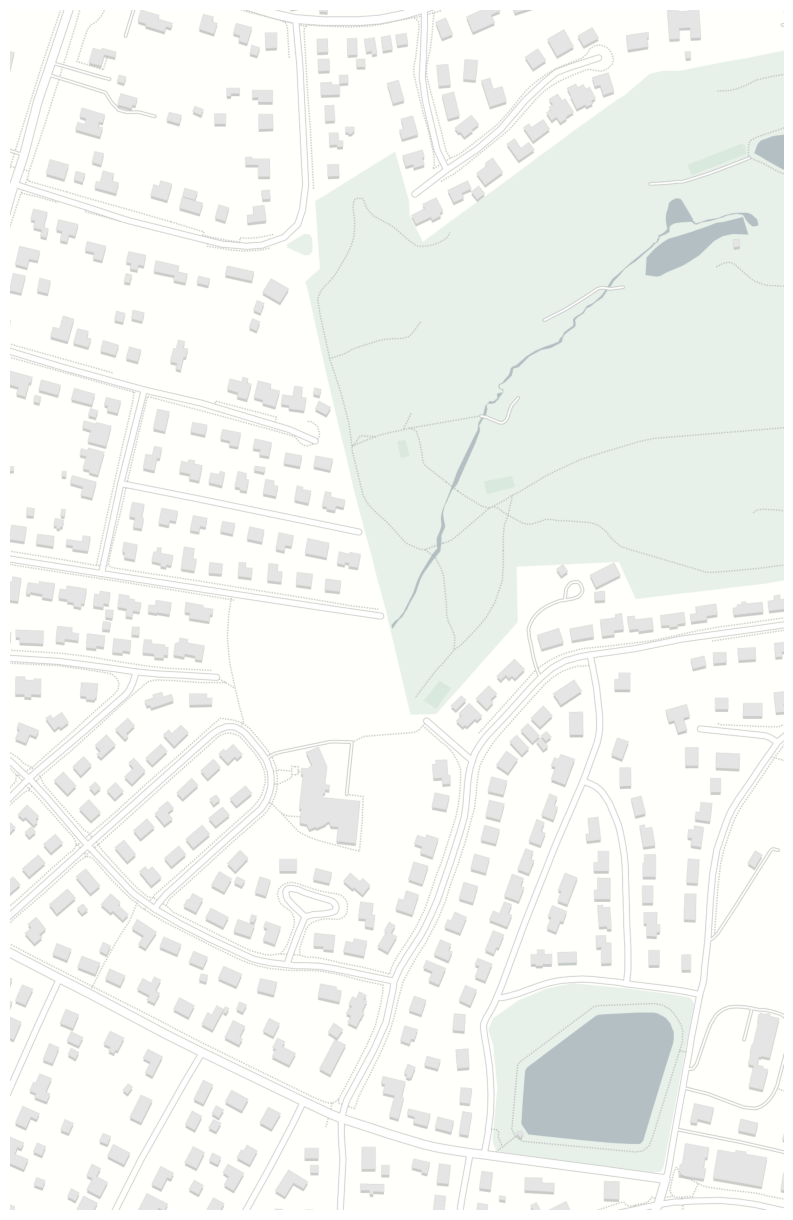


Export complete.

Pixel dimensions: 1453 × 2255

Print size at 300 DPI:
4.84 × 7.52 inches

PNG:     basemap.png
GeoTIFF: basemap.tif
BBox:    basemap_bbox.txt

Attribution when publishing:
© OpenStreetMap contributors © CARTO


In [24]:
# ============================================================
# BASEMAP EXPORT — ALL SETTINGS AT TOP
# Google Colab
#
# Requires:
#   selected_bbox
# from the previous interactive bounding-box map cell.
# ============================================================


# ============================================================
# SETTINGS — EDIT ONLY THIS SECTION
# ============================================================

# -------------------------
# BASE STYLE
# -------------------------
# Options:
# "Voyager"
# "Positron"
# "DarkMatter"

BASE_STYLE = "Positron"


# -------------------------
# MAP RESOLUTION
# -------------------------
# 16 = neighborhood
# 17 = detailed neighborhood
# 18 = school + park
# 19 = detailed site
# 20 = very detailed / larger download

ZOOM = 18


# -------------------------
# IMAGE APPEARANCE
# -------------------------
# 1.00 = original appearance
#
# SATURATION:
#   0.00 = grayscale
#   <1.0 = muted
#   >1.0 = more colorful
#
# CONTRAST:
#   <1.0 = softer
#   >1.0 = stronger
#
# BRIGHTNESS:
#   <1.0 = darker
#   >1.0 = lighter

SATURATION = 1.00
CONTRAST = 2.00
BRIGHTNESS = 1.00


# -------------------------
# EXPORT SETTINGS
# -------------------------

OUTPUT_DPI = 300

OUTPUT_NAME = "basemap"

OUTPUT_PNG = f"{OUTPUT_NAME}.png"
OUTPUT_TIF = f"{OUTPUT_NAME}.tif"
OUTPUT_BBOX = f"{OUTPUT_NAME}_bbox.txt"


# -------------------------
# PREVIEW SETTINGS
# -------------------------

PREVIEW_SIZE = 12

SHOW_PREVIEW = True


# ============================================================
# IMPORTS
# ============================================================

import contextily as cx
import xyzservices.providers as xyz
import numpy as np

from PIL import Image, ImageEnhance
from pyproj import Transformer

import rasterio
from rasterio.transform import from_bounds

import matplotlib.pyplot as plt
import os


# ============================================================
# BASEMAP STYLE SOURCES
# ============================================================

STYLE_SOURCES = {
    "Voyager": xyz.CartoDB.VoyagerNoLabels,
    "Positron": xyz.CartoDB.PositronNoLabels,
    "DarkMatter": xyz.CartoDB.DarkMatterNoLabels,
}


# ============================================================
# VALIDATE SETTINGS
# ============================================================

if BASE_STYLE not in STYLE_SOURCES:
    raise ValueError(
        f"Invalid BASE_STYLE: {BASE_STYLE}\n"
        f"Choose from: {list(STYLE_SOURCES.keys())}"
    )

TILE_SOURCE = STYLE_SOURCES[BASE_STYLE]


if "selected_bbox" not in globals() or selected_bbox is None:
    raise RuntimeError(
        "No bounding box selected.\n"
        "Go back to the interactive map and draw a rectangle first."
    )


# ============================================================
# READ BOUNDING BOX
# ============================================================

west, south, east, north = selected_bbox


print("Downloading map...")
print()

print("Settings:")
print(f"Base style:   {BASE_STYLE}")
print(f"Zoom:         {ZOOM}")
print(f"Saturation:   {SATURATION:.2f}")
print(f"Contrast:     {CONTRAST:.2f}")
print(f"Brightness:   {BRIGHTNESS:.2f}")
print(f"Output DPI:   {OUTPUT_DPI}")
print()

print("Bounding box:")
print(f"West:  {west:.6f}")
print(f"South: {south:.6f}")
print(f"East:  {east:.6f}")
print(f"North: {north:.6f}")
print()


# ============================================================
# DOWNLOAD BASEMAP
# ============================================================

img, tile_extent = cx.bounds2img(
    west,
    south,
    east,
    north,
    zoom=ZOOM,
    source=TILE_SOURCE,
    ll=True,
    n_connections=4
)

tile_min_x, tile_max_x, tile_min_y, tile_max_y = tile_extent


# ============================================================
# CONVERT BBOX TO WEB MERCATOR
# ============================================================

transformer = Transformer.from_crs(
    "EPSG:4326",
    "EPSG:3857",
    always_xy=True
)

bbox_min_x, bbox_min_y = transformer.transform(
    west,
    south
)

bbox_max_x, bbox_max_y = transformer.transform(
    east,
    north
)


# ============================================================
# CROP TO EXACT DRAWN RECTANGLE
# ============================================================

height, width = img.shape[:2]

x_resolution = (
    tile_max_x - tile_min_x
) / width

y_resolution = (
    tile_max_y - tile_min_y
) / height


left = int(round(
    (bbox_min_x - tile_min_x)
    / x_resolution
))

right = int(round(
    (bbox_max_x - tile_min_x)
    / x_resolution
))

top = int(round(
    (tile_max_y - bbox_max_y)
    / y_resolution
))

bottom = int(round(
    (tile_max_y - bbox_min_y)
    / y_resolution
))


left = max(0, left)
right = min(width, right)

top = max(0, top)
bottom = min(height, bottom)


cropped = img[
    top:bottom,
    left:right
]


if cropped.size == 0:
    raise RuntimeError(
        "Crop returned an empty image.\n"
        "Try drawing a slightly larger bounding box."
    )


# ============================================================
# CONVERT TO RGB
# ============================================================

cropped_uint8 = np.asarray(
    cropped
).astype(np.uint8)


if cropped_uint8.shape[2] == 4:

    map_image = Image.fromarray(
        cropped_uint8,
        mode="RGBA"
    ).convert("RGB")

else:

    map_image = Image.fromarray(
        cropped_uint8
    ).convert("RGB")


# ============================================================
# APPLY IMAGE ADJUSTMENTS
# ============================================================

map_image = ImageEnhance.Color(
    map_image
).enhance(
    SATURATION
)

map_image = ImageEnhance.Contrast(
    map_image
).enhance(
    CONTRAST
)

map_image = ImageEnhance.Brightness(
    map_image
).enhance(
    BRIGHTNESS
)


# ============================================================
# CONVERT FINAL IMAGE TO NUMPY
# ============================================================

final_img = np.array(
    map_image
).astype(np.uint8)

crop_height, crop_width = final_img.shape[:2]


# ============================================================
# SAVE PNG
# ============================================================

map_image.save(
    OUTPUT_PNG,
    dpi=(
        OUTPUT_DPI,
        OUTPUT_DPI
    )
)


# ============================================================
# GEOREFERENCE
# ============================================================

geo_transform = from_bounds(
    bbox_min_x,
    bbox_min_y,
    bbox_max_x,
    bbox_max_y,
    crop_width,
    crop_height
)


# ============================================================
# SAVE GEOTIFF
# ============================================================

with rasterio.open(
    OUTPUT_TIF,
    "w",
    driver="GTiff",
    height=crop_height,
    width=crop_width,
    count=3,
    dtype=np.uint8,
    crs="EPSG:3857",
    transform=geo_transform,
    compress="deflate"
) as dst:

    dst.write(
        final_img[:, :, 0],
        1
    )

    dst.write(
        final_img[:, :, 1],
        2
    )

    dst.write(
        final_img[:, :, 2],
        3
    )


# ============================================================
# SAVE BOUNDING BOX
# ============================================================

with open(
    OUTPUT_BBOX,
    "w"
) as f:

    f.write(
        "CRS: EPSG:4326\n"
    )

    f.write(
        f"west={west}\n"
    )

    f.write(
        f"south={south}\n"
    )

    f.write(
        f"east={east}\n"
    )

    f.write(
        f"north={north}\n"
    )


# ============================================================
# PREVIEW
# ============================================================

if SHOW_PREVIEW:

    plt.figure(
        figsize=(
            PREVIEW_SIZE,
            PREVIEW_SIZE
        )
    )

    plt.imshow(
        final_img
    )

    plt.axis("off")

    plt.tight_layout(
        pad=0
    )

    plt.show()


# ============================================================
# OUTPUT INFO
# ============================================================

print()
print("Export complete.")
print()

print(
    f"Pixel dimensions: "
    f"{crop_width} × {crop_height}"
)

print()

print(
    f"Print size at {OUTPUT_DPI} DPI:"
)

print(
    f"{crop_width / OUTPUT_DPI:.2f}"
    f" × "
    f"{crop_height / OUTPUT_DPI:.2f}"
    f" inches"
)

print()

print(f"PNG:     {OUTPUT_PNG}")
print(f"GeoTIFF: {OUTPUT_TIF}")
print(f"BBox:    {OUTPUT_BBOX}")

print()

print(
    "Attribution when publishing:"
)

print(
    "© OpenStreetMap contributors © CARTO"
)

# Download

In [25]:
from google.colab import files

files.download(OUTPUT_PNG)

# files.download(OUTPUT_TIF)
# files.download(OUTPUT_BBOX)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>